In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
# Helper functions for converting gate duration into duration-anharmonicity product
qb_anh_rads = 212.3e6 * (2 * np.pi) #anharmonicity in rad/s
def tg2prod(tg):
    return tg * (qb_anh_rads*1e-9) / (2*np.pi) #Convert anh to GHz since time on axis is in ns


def prod2tg(prod):
    return prod * (2*np.pi) / (qb_anh_rads*1e-9) #Convert anh to GHz since time on axis is in ns

# Leakage vs duration

(4.5, 20.0)

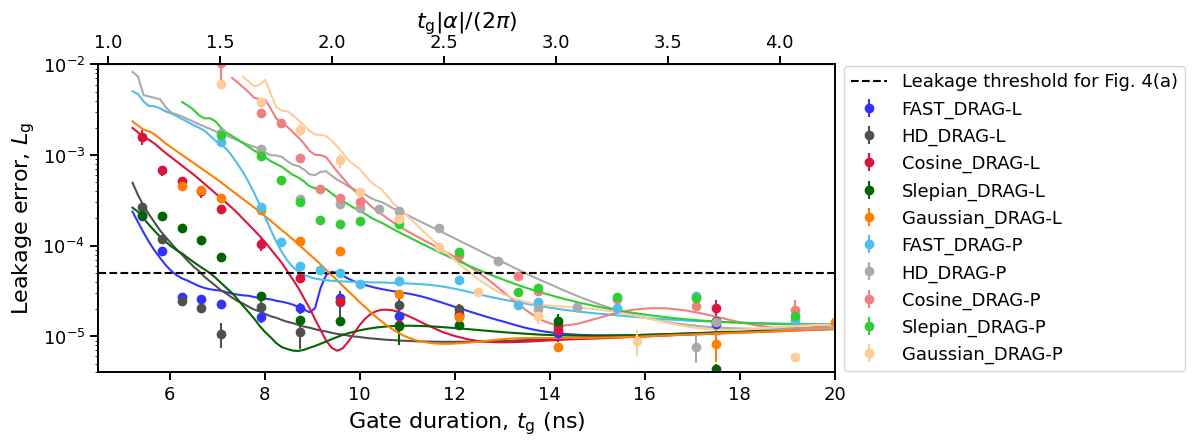

In [3]:
#Re-read csv-files and plot
pulse_names = ['FAST_DRAG-L', 'HD_DRAG-L', 'Cosine_DRAG-L', 'Slepian_DRAG-L', 'Gaussian_DRAG-L', 
               'FAST_DRAG-P', 'HD_DRAG-P', 'Cosine_DRAG-P', 'Slepian_DRAG-P', 'Gaussian_DRAG-P']

light_blue = [0.3010, 0.7450, 0.9330]
dark_blue = [51/255,51/255,255/255]
crimson = [220/255, 20/255, 60/255] 
light_red = [240/255,128/255,128/255]
light_green = [50/255,205/255,50/255]
dark_green = [0/255,100/255,0/255]
dark_orange = [255/255, 128/255, 0]
light_orange = [255/255, 204/255, 153/255]
dark_gray = [80/255, 80/255, 80/255] 
light_gray = [170/255, 170/255, 170/255]


colors_dict = {'FAST_DRAG-L': dark_blue, 'FAST_DRAG-P': light_blue, 
               'Cosine_DRAG-L': crimson,'Cosine_DRAG-P': light_red,
               'HD_DRAG-L': dark_gray, 'HD_DRAG-P': light_gray, 
               'Slepian_DRAG-L': dark_green, 'Slepian_DRAG-P': light_green, 
               'Gaussian_DRAG-L': dark_orange, 'Gaussian_DRAG-P': light_orange               
    }

#leakage vs duration
fig, ax = plt.subplots(1, 1, figsize=(9.5,4))
for pulse in pulse_names:
    #Experiments
    leakage_error_arr = np.genfromtxt('%s/leakage_error_exp_arr.csv'%(pulse), delimiter=',')
    leakage_error_uncertainty_arr = np.genfromtxt('%s/leakage_error_exp_uncertainty_arr.csv'%(pulse), delimiter=',')
    duration_arr = np.genfromtxt('%s/duration_exp_arr.csv'%(pulse), delimiter=',')
    plt.errorbar(duration_arr*1e9, leakage_error_arr, yerr=leakage_error_uncertainty_arr, fmt='o', color=colors_dict[pulse], label = '%s'%(pulse))
    #print(pulse, 'Minimum error %.4e at tg=%.3f ns'%(np.min(gate_error_arr), 1e9*duration_arr[np.argmin(gate_error_arr)]))
    #simulations
    leakage_error_sim_arr = np.genfromtxt('%s/leakage_error_sim_arr.csv'%(pulse), delimiter=',')
    duration_sim_arr = np.genfromtxt('%s/duration_sim_arr.csv'%(pulse), delimiter=',')
    plt.plot(duration_sim_arr*1e9, leakage_error_sim_arr, '-', color=colors_dict[pulse])

plt.plot([0, 25], [5e-5, 5e-5], 'k--', label='Leakage threshold for Fig. 4(a)')  
plt.xlabel('Gate duration, $t_\mathrm{g}$ (ns)', fontsize = 16)
plt.ylabel(r'Leakage error, $L_\mathrm{g}$', fontsize = 16)
ax.legend(loc='center left', fontsize=13, bbox_to_anchor=(1, 0.5))
secax = ax.secondary_xaxis('top', functions=(tg2prod, prod2tg))
secax.set_xlabel(r'$t_\mathrm{g}|\alpha|/(2\pi)$', fontsize=16)
ax.set_yscale("log")
ax.tick_params(length=6, width = 1.4, labelsize=13)
secax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
plt.ylim([4e-6, 1e-2])
plt.xlim([4.5, 20])

# Error vs duration

(4.5, 20.0)

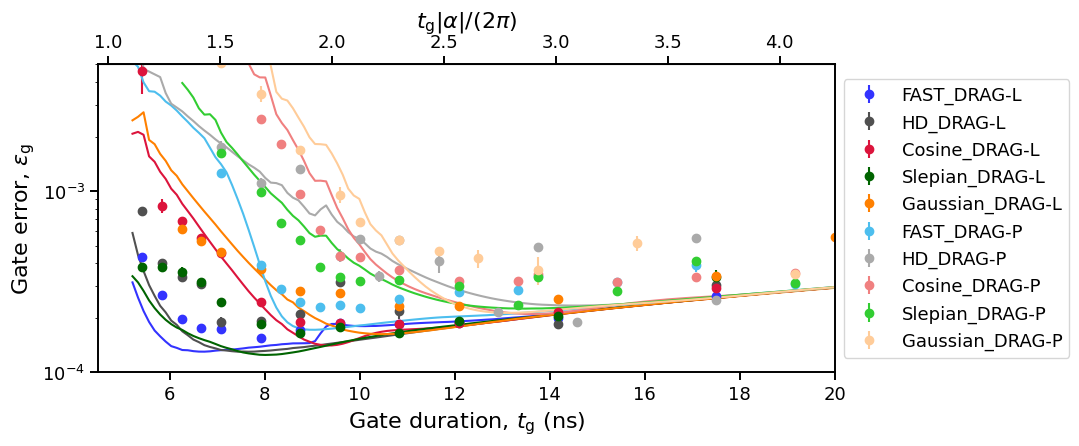

In [4]:
#Error vs duration
fig, ax = plt.subplots(1, 1, figsize=(9.5,4))
for pulse in pulse_names:
    #Experiments
    leakage_error_arr = np.genfromtxt('%s/gate_error_exp_arr.csv'%(pulse), delimiter=',')
    leakage_error_uncertainty_arr = np.genfromtxt('%s/gate_error_exp_uncertainty_arr.csv'%(pulse), delimiter=',')
    duration_arr = np.genfromtxt('%s/duration_exp_arr.csv'%(pulse), delimiter=',')
    plt.errorbar(duration_arr*1e9, leakage_error_arr, yerr=leakage_error_uncertainty_arr, fmt='o', color=colors_dict[pulse], label = '%s'%(pulse))
    #print(pulse, 'Minimum error %.4e at tg=%.3f ns'%(np.min(gate_error_arr), 1e9*duration_arr[np.argmin(gate_error_arr)]))
    #simulations
    leakage_error_sim_arr = np.genfromtxt('%s/gate_error_sim_arr.csv'%(pulse), delimiter=',')
    duration_sim_arr = np.genfromtxt('%s/duration_sim_arr.csv'%(pulse), delimiter=',')
    plt.plot(duration_sim_arr*1e9, leakage_error_sim_arr, '-', color=colors_dict[pulse])
    
plt.xlabel('Gate duration, $t_\mathrm{g}$ (ns)', fontsize = 16)
plt.ylabel(r'Gate error, $\varepsilon_\mathrm{g}$', fontsize = 16)
ax.legend(loc='center left', fontsize=13, bbox_to_anchor=(1, 0.5))
secax = ax.secondary_xaxis('top', functions=(tg2prod, prod2tg))
secax.set_xlabel(r'$t_\mathrm{g}|\alpha|/(2\pi)$', fontsize=16)
ax.set_yscale("log")
ax.tick_params(length=6, width = 1.4, labelsize=13)
secax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
plt.ylim([1e-4, 5e-3])
plt.xlim([4.5, 20])

# Pulse amplitude vs duration

(0.0, 2.0)

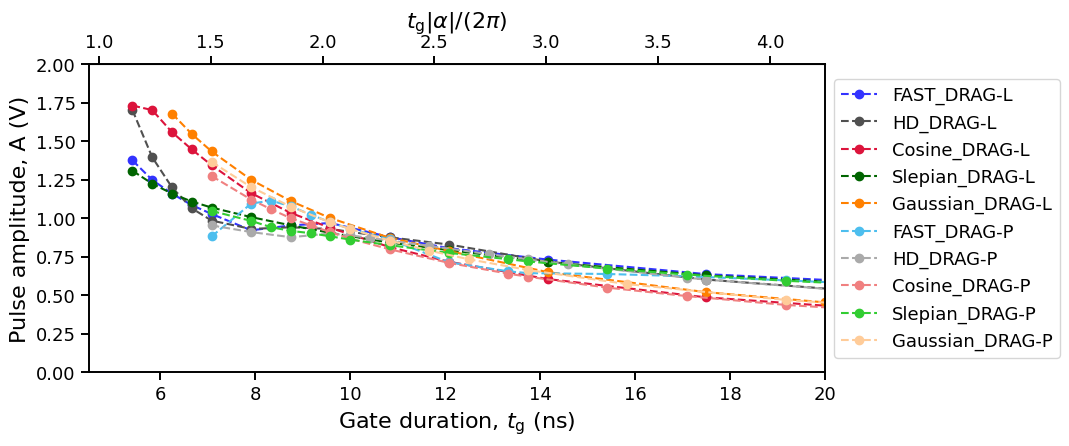

In [5]:
# Pulse amplitude vs duration
fig, ax = plt.subplots(1, 1, figsize=(9.5,4))
for pulse in pulse_names:
    #Experiments
    pulse_amplitude_arr = np.genfromtxt('%s/pulse_amplitude_arr.csv'%(pulse), delimiter=',')
    duration_arr = np.genfromtxt('%s/duration_exp_arr.csv'%(pulse), delimiter=',')
    plt.plot(duration_arr*1e9, pulse_amplitude_arr, 'o--', color=colors_dict[pulse], label = '%s'%(pulse))
    
plt.xlabel('Gate duration, $t_\mathrm{g}$ (ns)', fontsize = 16)
plt.ylabel(r'Pulse amplitude, A (V)', fontsize = 16)
ax.legend(loc='center left', fontsize=13, bbox_to_anchor=(1, 0.5))
secax = ax.secondary_xaxis('top', functions=(tg2prod, prod2tg))
secax.set_xlabel(r'$t_\mathrm{g}|\alpha|/(2\pi)$', fontsize=16)
ax.tick_params(length=6, width = 1.4, labelsize=13)
secax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
plt.xlim([4.5, 20])
plt.ylim([0, 2])